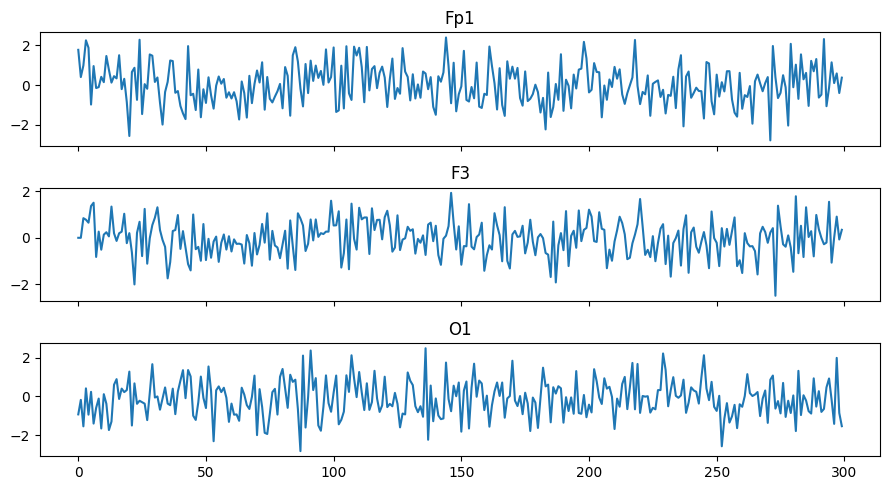

In [ ]:
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.stats import f as f_dist
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(0)
N = 300
lag_true = 2

ch1 = np.random.randn(N)               # bağımsız "kaynak" sinyal
ch2 = np.zeros(N)
for tt in range(lag_true, N):
    ch2[tt] = 0.7*ch1[tt-lag_true] + 0.3*np.random.randn()   # ch1 -> ch2, gecikmeli
ch3 = np.random.randn(N)               # tamamen bağımsız

channels = {"Fp1": ch1, "F3": ch2, "O1": ch3}

fig, axes = plt.subplots(3,1, figsize=(9,5), sharex=True)
for ax, (name, sig) in zip(axes, channels.items()):
    ax.plot(sig); ax.set_title(name)
plt.tight_layout(); plt.show()

In [ ]:
for name, sig in channels.items():
    result = adfuller(sig)
    print(f"{name}: ADF istatistiği={result[0]:.3f}, p-value={result[1]:.4f}",
          "(durağan)" if result[1] < 0.05 else "(durağan DEĞİL — fark almak gerekir)")

Fp1: ADF istatistiği=-17.839, p-value=0.0000 (durağan)
F3: ADF istatistiği=-4.687, p-value=0.0001 (durağan)
O1: ADF istatistiği=-17.671, p-value=0.0000 (durağan)


In [ ]:
def build_lagged_matrix(y, x_list, p):
    """y ve (varsa) x_list'teki serilerin p'ye kadar gecikmelerini içeren tasarım matrisi kurar."""
    N = len(y)
    rows = []
    target = []
    for t in range(p, N):
        row = [1.0]  # sabit terim (alpha0/beta0)
        for k in range(1, p+1):
            row.append(y[t-k])
        if x_list is not None:
            for x in x_list:
                for k in range(1, p+1):
                    row.append(x[t-k])
        rows.append(row)
        target.append(y[t])
    return np.array(rows), np.array(target)

def granger_test(x, y, p):
    # Kısıtlı model: y'nin kendi geçmişi
    X_restricted, target = build_lagged_matrix(y, None, p)
    model_r = sm.OLS(target, X_restricted).fit()
    RSS_j = np.sum(model_r.resid**2)

    # Tam model: y'nin kendi geçmişi + x'in geçmişi
    X_full, target2 = build_lagged_matrix(y, [x], p)
    model_f = sm.OLS(target2, X_full).fit()
    RSS_ij = np.sum(model_f.resid**2)

    N_eff = len(target)
    F_stat = ((RSS_j - RSS_ij)/p) / (RSS_ij/(N_eff - 2*p - 1))
    F_crit = f_dist.ppf(0.95, p, N_eff-2*p-1)   # alpha=0.05 kritik değer
    GC = np.log(RSS_j/RSS_ij) if RSS_ij > 0 else 0.0
    return F_stat, F_crit, GC

F_stat, F_crit, GC = granger_test(ch1, ch2, p=3)
print(f"Fp1 -> F3: F-istatistiği={F_stat:.2f}, kritik değer={F_crit:.2f}, GC={GC:.3f}")
print("Anlamlı mı?", "EVET" if F_stat > F_crit else "HAYIR")

Fp1 -> F3: F-istatistiği=540.00, kritik değer=2.64, GC=1.885
Anlamlı mı? EVET


In [ ]:
F_stat_rev, F_crit_rev, GC_rev = granger_test(ch2, ch1, p=3)
print(f"F3 -> Fp1: F={F_stat_rev:.2f}, kritik={F_crit_rev:.2f}, GC={GC_rev:.3f}",
      "-> Anlamlı mı?", F_stat_rev > F_crit_rev)

F_stat_o1, F_crit_o1, GC_o1 = granger_test(ch3, ch1, p=3)
print(f"O1 -> Fp1: F={F_stat_o1:.2f}, kritik={F_crit_o1:.2f}, GC={GC_o1:.3f}",
      "-> Anlamlı mı?", F_stat_o1 > F_crit_o1)

F3 -> Fp1: F=0.32, kritik=2.64, GC=0.003 -> Anlamlı mı? False
O1 -> Fp1: F=0.20, kritik=2.64, GC=0.002 -> Anlamlı mı? False


In [ ]:
names = list(channels.keys())
C = len(names)
A = np.eye(C)   # diagonal = 1 (Eş. 22)

for i in range(C):
    for j in range(C):
        if i != j:
            F_stat, F_crit, GC = granger_test(channels[names[i]], channels[names[j]], p=3)
            A[i,j] = GC if F_stat > F_crit else 0.0

print("Directed Adjacency Matrix (A):\n", np.round(A,3))
print("\nSimetrik mi?", np.allclose(A, A.T))

Directed Adjacency Matrix (A):
 [[1.    1.885 0.   ]
 [0.    1.    0.   ]
 [0.    0.    1.   ]]

Simetrik mi? False


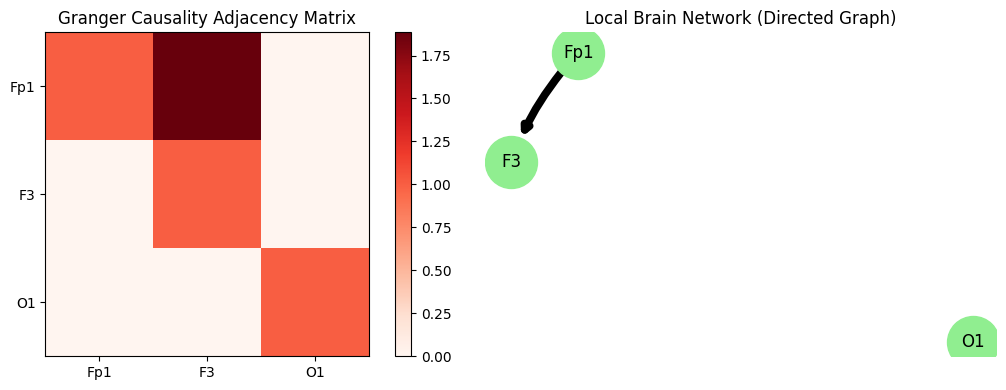

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(11,4))

im = axes[0].imshow(A, cmap='Reds', vmin=0)
axes[0].set_xticks(range(C)); axes[0].set_yticks(range(C))
axes[0].set_xticklabels(names); axes[0].set_yticklabels(names)
axes[0].set_title("Granger Causality Adjacency Matrix")
fig.colorbar(im, ax=axes[0])

G = nx.DiGraph()
G.add_nodes_from(names)
for i in range(C):
    for j in range(C):
        if i!=j and A[i,j] > 0:
            G.add_edge(names[i], names[j], weight=A[i,j])

pos = nx.spring_layout(G, seed=1)
weights = [G[u][v]['weight']*3 for u,v in G.edges()]
nx.draw(G, pos, ax=axes[1], with_labels=True, node_color='lightgreen',
        node_size=1400, width=weights, arrows=True, connectionstyle='arc3,rad=0.1')
axes[1].set_title("Local Brain Network (Directed Graph)")

plt.tight_layout(); plt.show()